Mapping des orbites : {0: 'Deep Space', 1: 'GEO', 2: 'LEO', 3: 'SSO'}


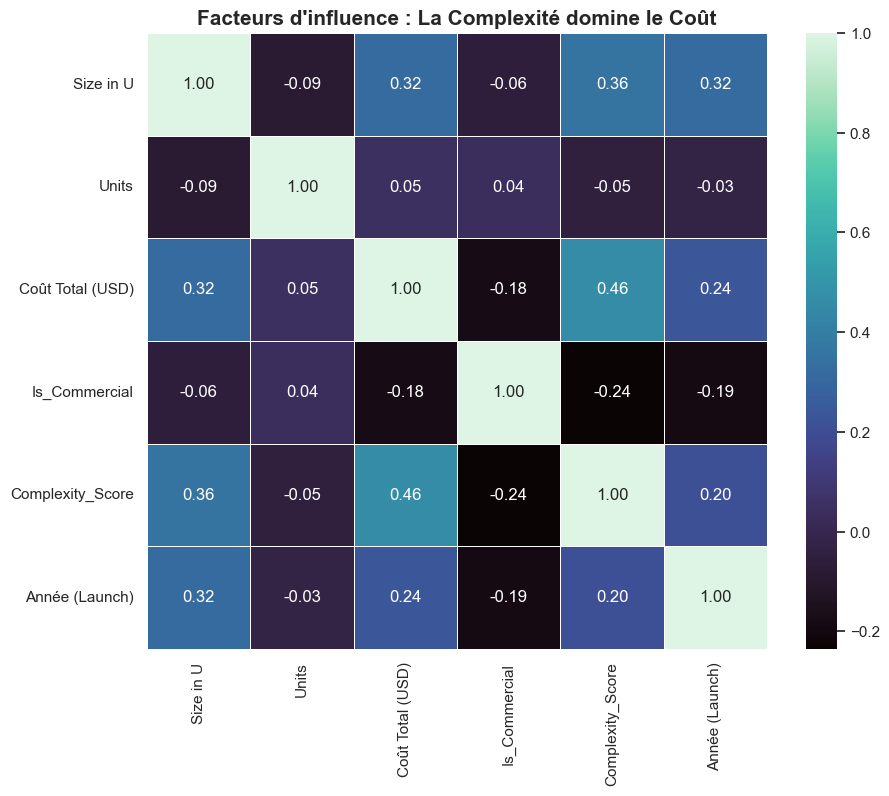

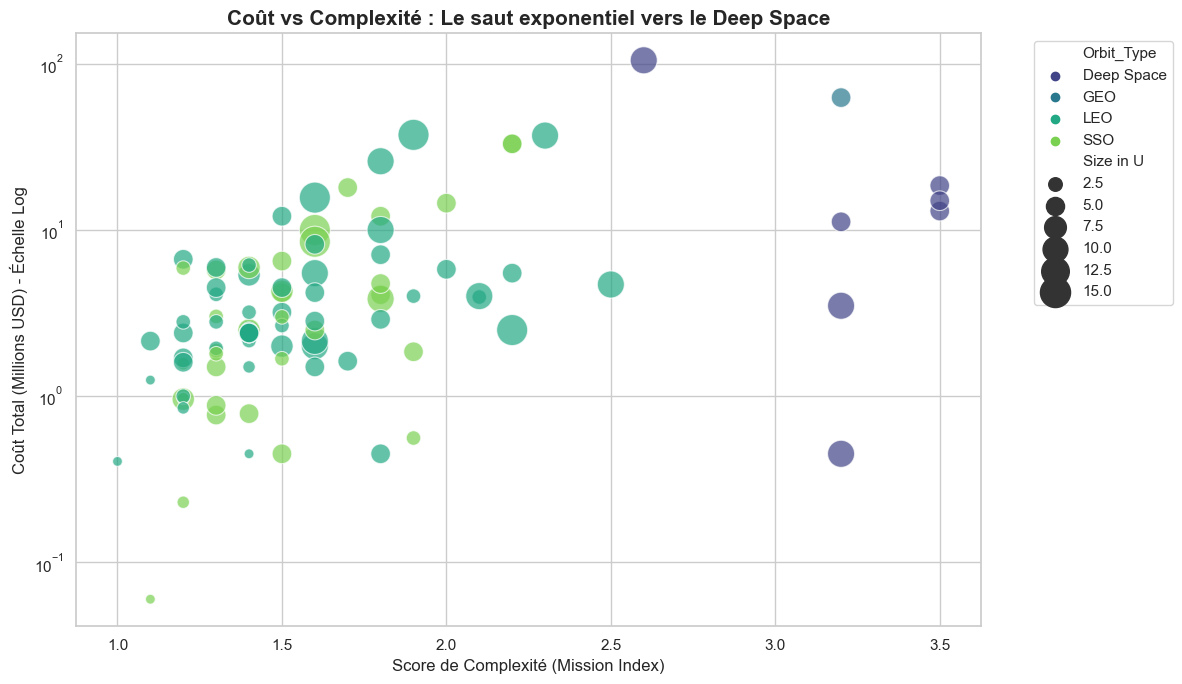

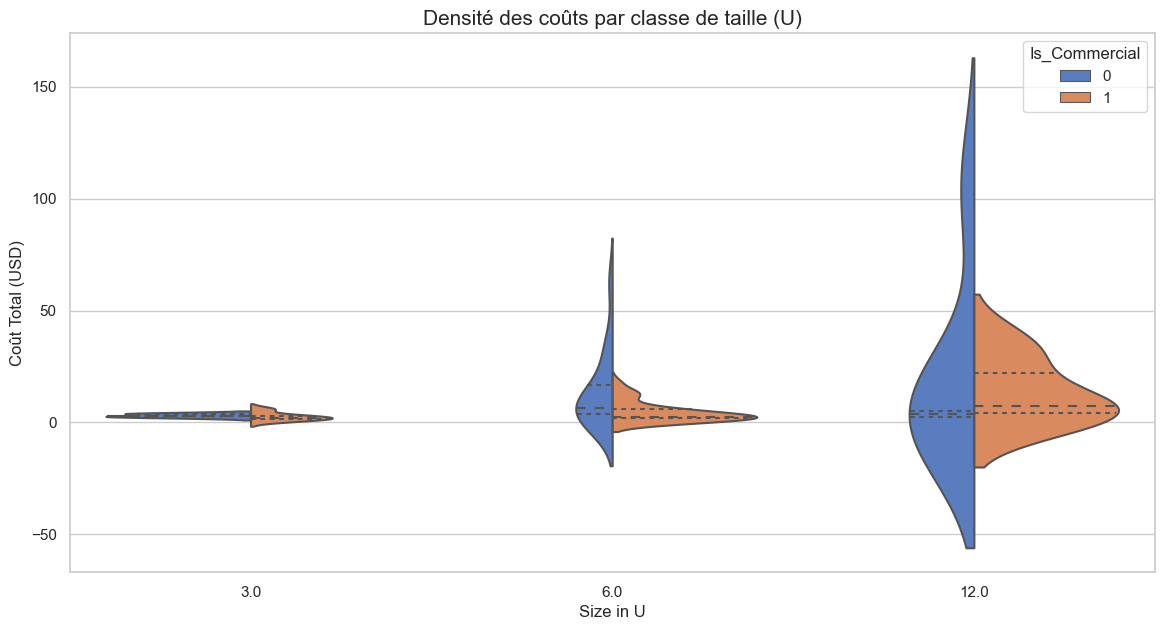

### Statistiques descriptives pour ton texte de poster :
|       |   Size in U |    Units |   Coût Total (USD) |   Is_Commercial |   Complexity_Score |   Année (Launch) |
|:------|------------:|---------:|-------------------:|----------------:|-------------------:|-----------------:|
| count |    99       | 99       |           99       |       99        |          99        |         99       |
| mean  |     6.33838 |  1.76768 |            7.33286 |        0.626263 |           1.67374  |       2022.26    |
| std   |     3.65741 |  1.89967 |           13.7029  |        0.486257 |           0.559626 |          2.57771 |
| min   |     1       |  1       |            0.06    |        0        |           1        |       2014       |
| 25%   |     3       |  1       |            1.825   |        0        |           1.3      |       2021       |
| 50%   |     6       |  1       |            3       |        1        |           1.5      |       2023       |
| 75%   |     6       |  1     

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION VISUELLE ---
# On choisit un style blanc et quadrillé, parfait pour l'impression sur poster
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 

# --- 2. CHARGEMENT ET NETTOYAGE ---
file_path = "ESA_CNES - CubeSeat Dataset - data.csv"
df = pd.read_csv(file_path)

df['Orbit_Type'] = df['Orbit_Type'].astype('category')
orbit_names = df['Orbit_Type'].cat.categories
df['orbit_idx'] = df['Orbit_Type'].cat.codes

print(f"Mapping des orbites : {dict(enumerate(orbit_names))}")

# Nettoyage de la colonne Coût : on remplace la virgule par un point et on convertit en float
df['Coût Total (USD)'] = pd.to_numeric(df['Coût Total (USD)'], errors='coerce')
df = df.dropna(subset=['Coût Total (USD)'])
df['Size in U'] = df['Size in U'].astype(float)

# --- 3. GÉNÉRATION DE LA MATRICE DE CORRÉLATION ---
plt.figure(figsize=(10, 8))
# On ne garde que les colonnes numériques pour la corrélation
numeric_cols = ['Size in U', 'Units', 'Coût Total (USD)', 'Is_Commercial', 'Complexity_Score', 'Année (Launch)']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='mako', fmt=".2f", linewidths=0.5)
plt.title("Facteurs d'influence : La Complexité domine le Coût", fontsize=15, fontweight='bold')
plt.show()

# --- 4. SCATTER PLOT (LE PLAN KNN) ---
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='Complexity_Score', 
    y='Coût Total (USD)', 
    hue='Orbit_Type', 
    size='Size in U', 
    sizes=(50, 500), 
    alpha=0.7,
    palette="viridis"
)
plt.yscale('log') # Échelle log car les coûts varient de 0.06 à 105M$
plt.title("Coût vs Complexité : Le saut exponentiel vers le Deep Space", fontsize=15, fontweight='bold')
plt.xlabel("Score de Complexité (Mission Index)", fontsize=12)
plt.ylabel("Coût Total (Millions USD) - Échelle Log", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 5. VIOLIN PLOT (DISTRIBUTION ET DENSITÉ) ---
plt.figure(figsize=(14, 7))
sns.violinplot(
    data=df[df['Size in U'].isin([3, 6, 12])], # On se concentre sur les tailles standards
    x='Size in U', 
    y='Coût Total (USD)', 
    hue='Is_Commercial', 
    split=True,     # Permet de comparer Commercial vs Institutionnel sur le même "violon"
    inner="quart",  # Affiche les quartiles à l'intérieur
    palette="muted"
)
plt.title("Densité des coûts par classe de taille (U)", fontsize=15)
plt.show()


# --- 6. EXPORT DES STATS POUR LE POSTER ---
print("### Statistiques descriptives pour ton texte de poster :")
print(df[numeric_cols].describe().to_markdown())

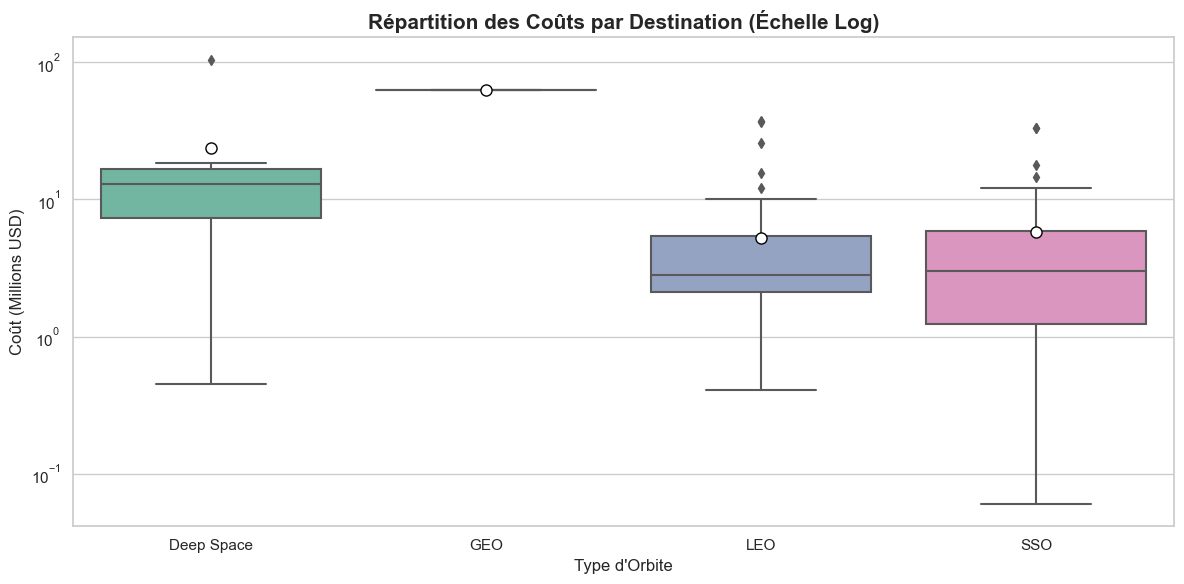

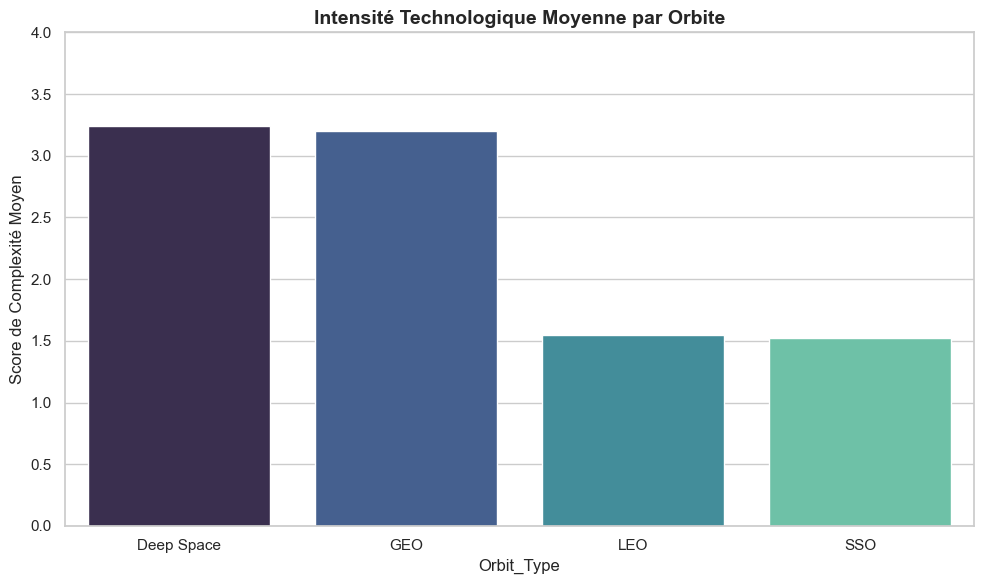

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


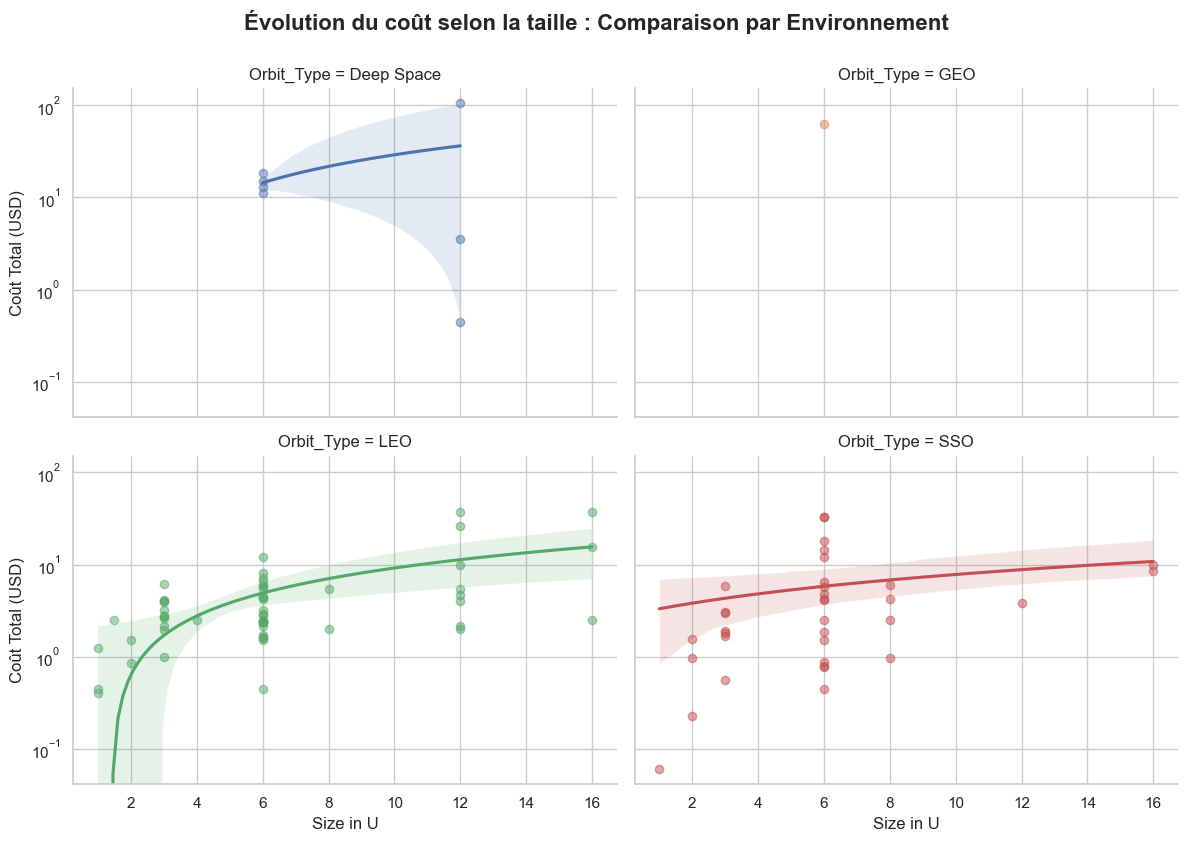

### Statistiques moyennes par type d'orbite :
| Orbit_Type   |   ('Coût Total (USD)', 'mean') |   ('Coût Total (USD)', 'median') |   ('Coût Total (USD)', 'count') |   ('Complexity_Score', 'mean') |
|:-------------|-------------------------------:|---------------------------------:|--------------------------------:|-------------------------------:|
| Deep Space   |                          23.81 |                             13   |                               7 |                           3.24 |
| GEO          |                          62.6  |                             62.6 |                               1 |                           3.2  |
| LEO          |                           5.27 |                              2.8 |                              56 |                           1.54 |
| SSO          |                           5.75 |                              3   |                              35 |                           1.52 |


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 

# --- 2. CHARGEMENT ET PRÉPARATION ---
file_path = "ESA_CNES - CubeSeat Dataset - data.csv"
df = pd.read_csv(file_path)

# Nettoyage et conversion
df['Coût Total (USD)'] = pd.to_numeric(df['Coût Total (USD)'], errors='coerce')
df = df.dropna(subset=['Coût Total (USD)'])
df['Size in U'] = df['Size in U'].astype(float)
df['Orbit_Type'] = df['Orbit_Type'].astype('category')

# --- 3. BOXPLOT : LA RÉALITÉ FINANCIÈRE DES ORBITES ---
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df, 
    x='Orbit_Type', 
    y='Coût Total (USD)', 
    palette="Set2",
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)
plt.yscale('log')
plt.title("Répartition des Coûts par Destination (Échelle Log)", fontsize=15, fontweight='bold')
plt.ylabel("Coût (Millions USD)")
plt.xlabel("Type d'Orbite")
plt.tight_layout()
plt.show()

# --- 4. BARPLOT : COMPLEXITÉ VS ORBITE ---
# Est-ce que les missions lointaines sont vraiment plus complexes ?
plt.figure(figsize=(10, 6))
avg_complexity = df.groupby('Orbit_Type')['Complexity_Score'].mean().sort_values()
sns.barplot(x=avg_complexity.index, y=avg_complexity.values, palette="mako")
plt.title("Intensité Technologique Moyenne par Orbite", fontsize=14, fontweight='bold')
plt.ylabel("Score de Complexité Moyen")
plt.ylim(0, 4) # On garde l'échelle de ton score
plt.tight_layout()
plt.show()

# --- 5. FACET GRID : TAILLE VS COÛT PAR ORBITE ---
# Pour voir si 1U en LEO coûte la même chose qu'un 1U en Deep Space
g = sns.FacetGrid(df, col="Orbit_Type", hue="Orbit_Type", col_wrap=2, height=4, aspect=1.5)
g.map(sns.regplot, "Size in U", "Coût Total (USD)", scatter_kws={'alpha':0.5})
g.set(yscale="log")
g.fig.suptitle("Évolution du coût selon la taille : Comparaison par Environnement", fontsize=16, fontweight='bold', y=1.05)
plt.show()

# --- 6. EXPORT DES STATS PAR ORBITE (Pour tes légendes) ---
print("### Statistiques moyennes par type d'orbite :")
orbit_stats = df.groupby('Orbit_Type').agg({
    'Coût Total (USD)': ['mean', 'median', 'count'],
    'Complexity_Score': 'mean'
}).round(2)
print(orbit_stats.to_markdown())

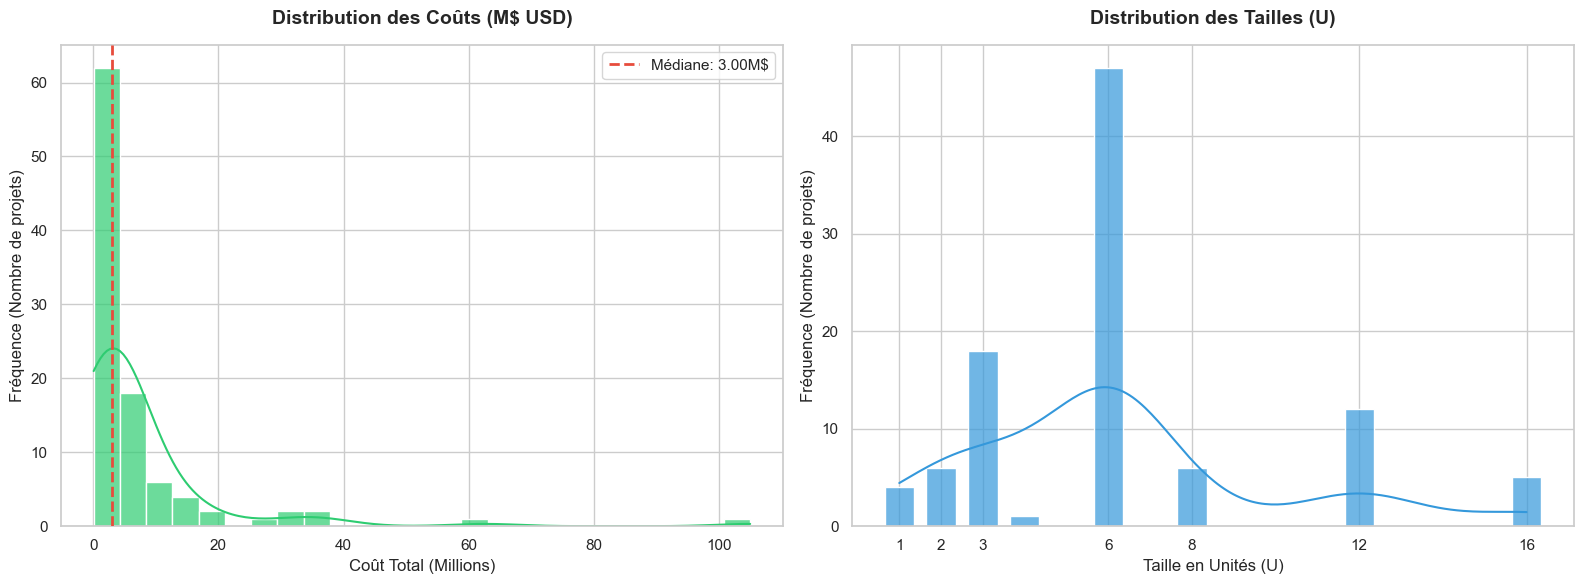

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid") # Grille propre en arrière-plan

# --- GAUCHE : Distribution des COÛTS (Vert Émeraude) ---
sns.histplot(df['Coût Total (USD)'], kde=True, color="#2ecc71", ax=ax1, bins=25, alpha=0.7)
ax1.set_title('Distribution des Coûts (M$ USD)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Coût Total (Millions)', fontsize=12)
ax1.set_ylabel('Fréquence (Nombre de projets)', fontsize=12)

# Ajout de la médiane en rouge
median_cost = df['Coût Total (USD)'].median()
ax1.axvline(median_cost, color='#e74c3c', linestyle='--', linewidth=2, label=f'Médiane: {median_cost:.2f}M$', zorder=3)
ax1.legend()

# --- DROITE : Distribution des TAILLES (Bleu Ciel) ---
# Note : discrete=True est crucial ici pour que les barres s'alignent sur 1, 2, 3, 6...
sns.histplot(df['Size in U'], color="#3498db", ax=ax2, discrete=True, shrink=0.7, kde=True, alpha=0.7)
ax2.set_title('Distribution des Tailles (U)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Taille en Unités (U)', fontsize=12)
ax2.set_ylabel('Fréquence (Nombre de projets)', fontsize=12)

# On force l'affichage des paliers standards des CubeSats
standard_units = [1, 2, 3, 6, 8, 12, 16]
ax2.set_xticks(standard_units)


# --- 3. Finition et Affichage ---
plt.tight_layout()

# Optionnel : Sauvegarde pour le poster (haute résolution)
# plt.savefig("distributions_cubesat_ESA.png", dpi=300, bbox_inches='tight')

plt.show()

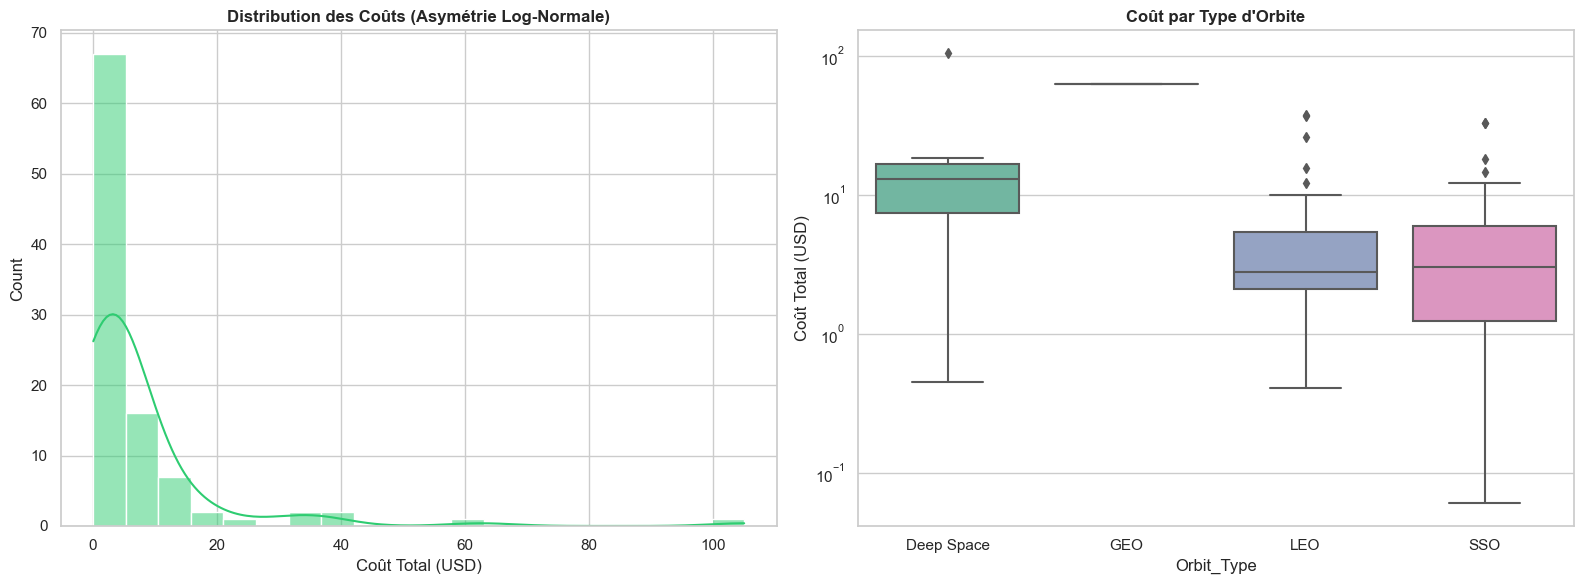

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(df['Coût Total (USD)'], kde=True, color="#2ecc71", ax=ax1, bins=20)
ax1.set_title('Distribution des Coûts (Asymétrie Log-Normale)', fontweight='bold')

sns.boxplot(data=df, x='Orbit_Type', y='Coût Total (USD)', palette="Set2", ax=ax2)
ax2.set_title('Coût par Type d\'Orbite', fontweight='bold')
ax2.set_yscale('log')
plt.tight_layout()
plt.show()

analyse

In [3]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az

# 1. Préparation des données
df = pd.read_csv("ESA_CNES - CubeSeat Dataset - data.csv")

# On centre l'année pour aider le modèle à converger (2024 = 0)
df['Year_Scaled'] = df['Année (Launch)'] - 2024
df['Orbit_Type'] = df['Orbit_Type'].astype('category')
orbit_names = df['Orbit_Type'].cat.categories
df['orbit_idx'] = df['Orbit_Type'].cat.codes
# Suppression de la ligne vide si nécessaire
df = df.dropna(subset=['Coût Total (USD)'])

n_orbits = len(orbit_names)
# 2. Construction du Modèle Bayésien
with pm.Model() as cubesat_model:
    # --- Priors (nos hypothèses de départ) ---
    alpha_orbit = pm.Normal("alpha_orbit", mu=0, sigma=1.5, shape=n_orbits)
    beta_size = pm.Normal("beta_size", mu=0.5, sigma=1)
    beta_complexity = pm.Normal("beta_complexity", mu=1, sigma=1) # On s'attend à un effet fort
    beta_comm = pm.Normal("beta_comm", mu=0, sigma=1)
    beta_year = pm.Normal("beta_year", mu=0, sigma=1)
    
    sigma = pm.HalfNormal("sigma", sigma=1) # Incertitude du modèle
    
    # --- Équation de la moyenne (Log-Link) ---
    mu = (alpha_orbit[df.orbit_idx.values] + 
          beta_size * df['Size in U'].values + 
          beta_complexity * df['Complexity_Score'].values +
          beta_comm * df['Is_Commercial'].values + 
          beta_year * df['Year_Scaled'].values)
    
    # --- Likelihood (La loi Log-Normale) ---
    y_obs = pm.LogNormal("y_obs", mu=mu, sigma=sigma, observed=df['Coût Total (USD)'].values)
    
    # --- Inférence (Le modèle "apprend") ---
    trace = pm.sample(2000, tune=1000, target_accept=0.95)

# 3. Visualisation des résultats


c:\Users\BRAVO\.conda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_orbit, beta_size, beta_complexity, beta_comm, beta_year, sigma]


c:\Users\BRAVO\.conda\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 105 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha_orbit[0]  -1.212  0.814  -2.725    0.337      0.020    0.013    1651.0   
alpha_orbit[1]   0.491  1.004  -1.507    2.301      0.020    0.015    2544.0   
alpha_orbit[2]  -0.609  0.414  -1.363    0.195      0.010    0.007    1662.0   
alpha_orbit[3]  -0.701  0.428  -1.492    0.104      0.010    0.008    1740.0   
beta_size        0.088  0.032   0.028    0.147      0.001    0.001    3257.0   
beta_complexity  0.886  0.252   0.377    1.332      0.006    0.004    1710.0   
beta_comm       -0.123  0.210  -0.519    0.276      0.003    0.003    3800.0   
beta_year        0.039  0.042  -0.043    0.113      0.001    0.001    3075.0   
sigma            1.009  0.074   0.863    1.141      0.001    0.001    3686.0   

                 ess_tail  r_hat  
alpha_orbit[0]     2259.0    1.0  
alpha_orbit[1]     3001.0    1.0  
alpha_orbit[2]     1901.0    1.0  
alpha_orbit[3]     2121.0    1.0  
beta_size          2572.

<Figure size 1000x600 with 0 Axes>

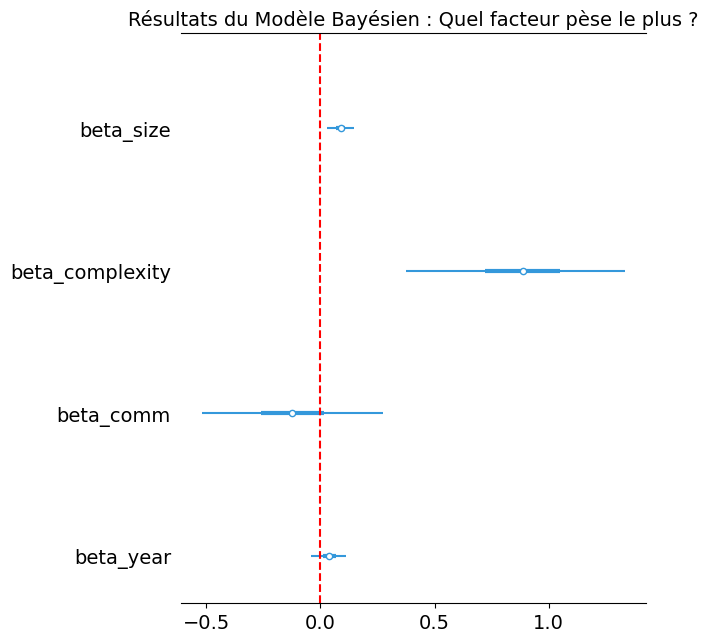

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
print(az.summary(trace))
plt.figure(figsize=(10, 6))
az.plot_forest(trace, var_names=["beta_size", "beta_complexity", "beta_comm", "beta_year"], combined=True, colors="#3498db")
plt.axvline(0, color='red', linestyle='--')
plt.title("Résultats du Modèle Bayésien : Quel facteur pèse le plus ?", fontsize=14)
plt.show()

<Figure size 1000x600 with 0 Axes>

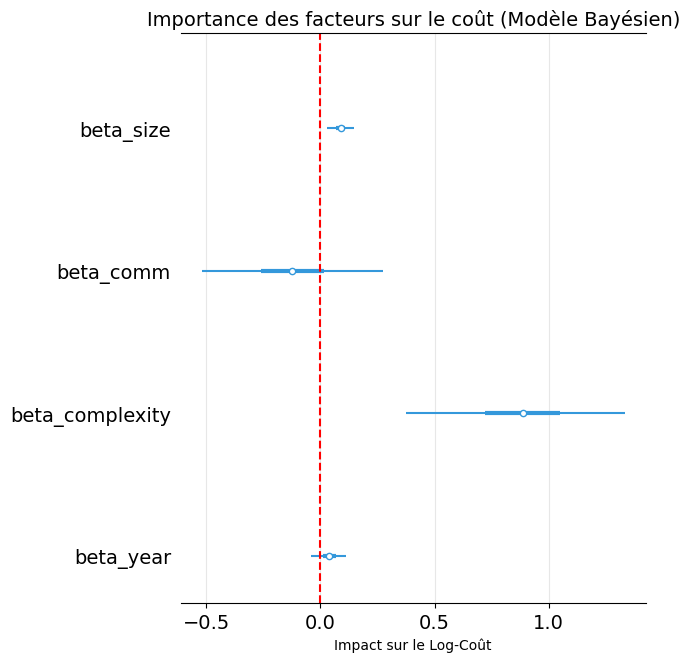

In [5]:
import arviz as az
import matplotlib.pyplot as plt

# On utilise les résultats que tu as obtenus
plt.figure(figsize=(10, 6))
az.plot_forest(trace, var_names=["beta_size", "beta_comm", "beta_complexity", "beta_year"], 
               combined=True, 
               colors="#3498db",
               kind='forestplot')

plt.axvline(0, color='red', linestyle='--') # La ligne du "zéro" effet
plt.title("Importance des facteurs sur le coût (Modèle Bayésien)", fontsize=14)
plt.xlabel("Impact sur le Log-Coût")
plt.grid(axis='x', alpha=0.3)

# Sauvegarde pour le poster
# plt.savefig("bayes_forest_plot.png", dpi=300)
plt.show()

In [7]:
print(df.head())

   id               Project  Size in U  Units  Coût Total (USD)  \
0   0           AeroCube-15        3.0      1             4.100   
1   1  AISTECHSAT (DANU) 2U        2.0      1             0.230   
2   2                 Amber        6.0      2             5.750   
3   3         IOD Mission 3        6.0      4             2.145   
4   4              BlackCAT        6.0      1             5.800   

   Is_Commercial  Incl_Launch  Année (Launch)       Mission_Type  \
0              0            1            2022    Technology Demo   
1              1            0            2019  Earth Observation   
2              1            1            2024     Communications   
3              1            0            2023    Technology Demo   
4              1            0            2024  Science/Astronomy   

   Complexity_Score Orbit_Type  Year_Scaled  
0               1.3        LEO           -2  
1               1.2        SSO           -5  
2               1.3        SSO            0  
3   

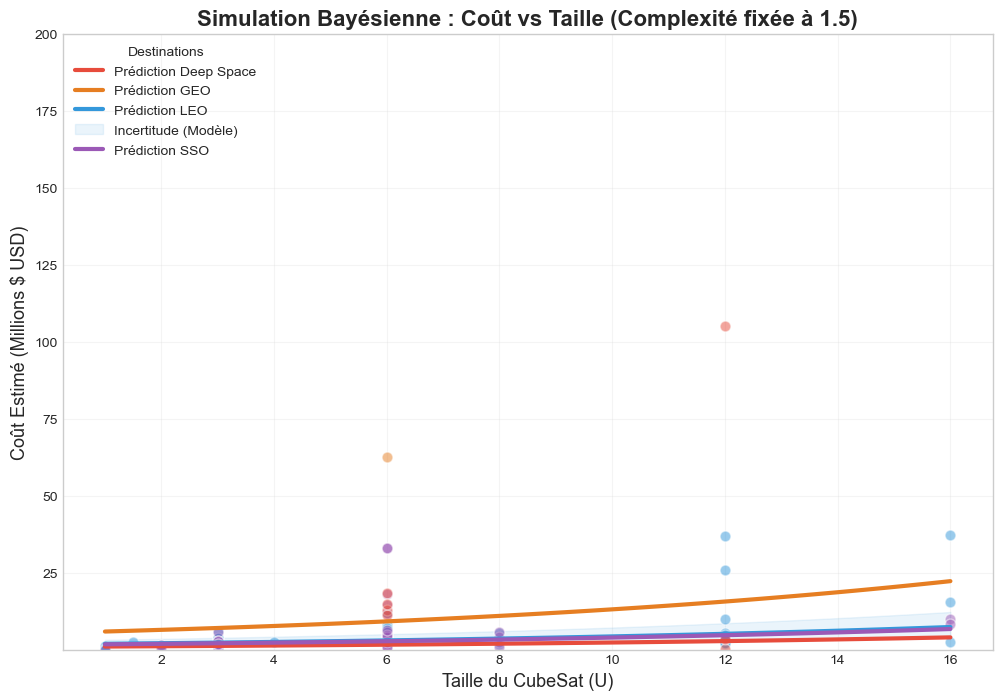

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Paramètres extraits de ton nouveau modèle ---
# Coefficients moyens (mean)
alphas = {
    "Deep Space": -1.212,
    "GEO": 0.491,
    "LEO": -0.609,
    "SSO": -0.701
}
b_size = 0.088
b_complexity = 0.886  # La grande nouveauté
b_comm = -0.123
sigma = 1.009

# --- 2. Fonction de prédiction ---
def predict_cubesat_cost(size, complexity, orbit_name, is_comm=1):
    alpha = alphas[orbit_name]
    # Equation : exp(alpha + b1*size + b2*complexity + b3*comm)
    log_mu = alpha + (b_size * size) + (b_complexity * complexity) + (b_comm * is_comm)
    return np.exp(log_mu)

# --- 3. Génération des données pour le graphique ---
sizes = np.linspace(1, 16, 100)
# On simule pour une complexité "standard" de 1.5
complexity_std = 1.5 

plt.figure(figsize=(12, 8))

# Calcul pour chaque orbite
colors = {"LEO": "#3498db", "SSO": "#9b59b6", "GEO": "#e67e22", "Deep Space": "#e74c3c"}

for orbit, alpha_val in alphas.items():
    costs = predict_cubesat_cost(sizes, complexity_std, orbit)
    plt.plot(sizes, costs, label=f'Prédiction {orbit}', color=colors[orbit], lw=3)
    
    # Ajout de l'ombre d'incertitude (HDI) pour le LEO à titre d'exemple
    if orbit == "LEO":
        lower = np.exp((alpha_val + b_size*sizes + b_complexity*complexity_std + b_comm*1) - 0.5*sigma)
        upper = np.exp((alpha_val + b_size*sizes + b_complexity*complexity_std + b_comm*1) + 0.5*sigma)
        plt.fill_between(sizes, lower, upper, color=colors[orbit], alpha=0.1, label='Incertitude (Modèle)')

# --- 4. Comparaison avec les données réelles ---
df = pd.read_csv("ESA_CNES - CubeSeat Dataset - data.csv")

# On affiche les points réels colorés par leur orbite
for orbit in df['Orbit_Type'].unique():
    subset = df[df['Orbit_Type'] == orbit]
    plt.scatter(subset['Size in U'], subset['Coût Total (USD)'], alpha=0.5, c=colors.get(orbit, 'grey'), s=60, edgecolors='w')

# --- 5. Cosmétique ---
plt.title(f"Simulation Bayésienne : Coût vs Taille (Complexité fixée à {complexity_std})", fontsize=16, fontweight='bold')
plt.xlabel("Taille du CubeSat (U)", fontsize=13)
plt.ylabel("Coût Estimé (Millions $ USD)", fontsize=13)
plt.yscale('log')
plt.ylim(0.1, 200)
plt.legend(title="Destinations", loc='upper left')
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()